In [2]:
import os
import json
import sqlite3
import time
import warnings
import io
import shutil
import traceback
import urllib.request
from pathlib import Path
from datetime import datetime

import numpy as np
import torch
import onnxruntime as ort
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.gridspec import GridSpec
from PIL import Image, ImageOps

from ultralytics import YOLO
from facenet_pytorch import MTCNN
from facenet_pytorch.models.mtcnn import PNet, RNet, ONet

In [ ]:
import zipfile

zip_path = "/content/drive/MyDrive/MainProject/human_dataset.zip"
extract_path = "/content/drive/MyDrive/MainProject/human_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")


Extraction completed!


In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 28.4 MB/s eta 0:00:00


In [ ]:
import os
from pathlib import Path
from ultralytics import YOLO
import torch

# ─────────────────────────────────────────
# CONFIGURE THESE
# ─────────────────────────────────────────
DATASET_YAML  = "/content/drive/MyDrive/MainProject/human_dataset/human_dataset/dataset.yaml"
MODEL         = "yolov8s.pt"          # yolov8s = small, good balance of speed/accuracy
EPOCHS        = 50
IMG_SIZE      = 640
BATCH_SIZE    = 16                    # lower to 8 if you get OOM errors
PROJECT_NAME  = "human_detection"
RUN_NAME      = "yolov8s_run1"
DEVICE        = 0 if torch.cuda.is_available() else "cpu"
# ─────────────────────────────────────────


def train():
    print(f"\n🚀 Training on: {'GPU - ' + torch.cuda.get_device_name(0) if DEVICE == 0 else 'CPU'}")
    print(f"📦 Model       : {MODEL}")
    print(f"📁 Dataset     : {DATASET_YAML}")
    print(f"🔁 Epochs      : {EPOCHS}\n")

    model = YOLO(MODEL)

    results = model.train(
        data        = DATASET_YAML,
        epochs      = EPOCHS,
        imgsz       = IMG_SIZE,
        batch       = BATCH_SIZE,
        device      = DEVICE,
        project     = PROJECT_NAME,
        name        = RUN_NAME,
        workers     = 4,
        patience    = 15,           # early stopping if no improvement for 15 epochs
        save        = True,
        save_period = 10,           # save checkpoint every 10 epochs
        exist_ok    = True,
        pretrained  = True,
        optimizer   = "AdamW",
        lr0         = 0.001,
        momentum    = 0.937,
        weight_decay= 0.0005,
        augment     = True,
        verbose     = True,
    )

    print("\n✅ Training complete!")
    print(f"📂 Results saved to → {PROJECT_NAME}/{RUN_NAME}")
    return model


def evaluate(model=None):
    # If no model passed in, load the best weights from training
    best_weights = Path(PROJECT_NAME) / RUN_NAME / "weights" / "best.pt"

    if model is None:
        print(f"\n📥 Loading best weights from: {best_weights}")
        model = YOLO(str(best_weights))

    print("\n📊 Running Evaluation on Validation Set...")
    val_results = model.val(
        data    = DATASET_YAML,
        imgsz   = IMG_SIZE,
        batch   = BATCH_SIZE,
        device  = DEVICE,
        split   = "val",            # change to "test" to eval on test set
        verbose = True,
        project = PROJECT_NAME,
        name    = RUN_NAME + "_val_eval",
        exist_ok= True,
    )

    print("\n📊 Running Evaluation on Test Set...")
    test_results = model.val(
        data    = DATASET_YAML,
        imgsz   = IMG_SIZE,
        batch   = BATCH_SIZE,
        device  = DEVICE,
        split   = "test",
        verbose = True,
        project = PROJECT_NAME,
        name    = RUN_NAME + "_test_eval",
        exist_ok= True,
    )

    print_metrics(val_results,  label="VALIDATION")
    print_metrics(test_results, label="TEST")


def print_metrics(results, label=""):
    print(f"\n{'='*45}")
    print(f"  📈 {label} METRICS")
    print(f"{'='*45}")
    print(f"  Precision  (P)  : {results.results_dict.get('metrics/precision(B)', 0):.4f}")
    print(f"  Recall     (R)  : {results.results_dict.get('metrics/recall(B)', 0):.4f}")
    print(f"  mAP@0.5         : {results.results_dict.get('metrics/mAP50(B)', 0):.4f}")
    print(f"  mAP@0.5:0.95    : {results.results_dict.get('metrics/mAP50-95(B)', 0):.4f}")
    print(f"  Fitness Score   : {results.results_dict.get('fitness', 0):.4f}")
    print(f"{'='*45}\n")


if __name__ == "__main__":
    # Train then immediately evaluate
    trained_model = train()
    evaluate(trained_model)
# ```

# ---

# **Quick breakdown of what you get:**

# **Training goodies:**
# - Loads pretrained `yolov8s.pt` weights (transfer learning)
# - Early stopping with patience of 15 epochs so it doesn't overfit
# - AdamW optimizer with solid default hyperparameters
# - Saves best + last checkpoints automatically
# - All logs, curves, and weights go into `human_detection/yolov8s_run1/`

# **Evaluation metrics printed:**
# - **Precision** — of all detections, how many were actually humans
# - **Recall** — of all actual humans, how many were detected
# - **mAP@0.5** — main detection accuracy metric
# - **mAP@0.5:0.95** — stricter overall accuracy
# - **Fitness Score** — YOLOv8's combined metric

# **After training your results folder will have:**
# ```
# human_detection/yolov8s_run1/
# ├── weights/
# │   ├── best.pt       ← use this for inference
# │   └── last.pt
# ├── results.csv
# ├── confusion_matrix.png
# ├── PR_curve.png
# ├── F1_curve.png
# └── results.png       ← all training curves in one image


🚀 Training on: GPU - Tesla T4
📦 Model       : yolov8s.pt
📁 Dataset     : /content/drive/MyDrive/MainProject/human_dataset/human_dataset/dataset.yaml
🔁 Epochs      : 50

Ultralytics 8.4.14 🚀 Python-3.12.12 torch-2.9.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/drive/MyDrive/MainProject/human_dataset/human_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det

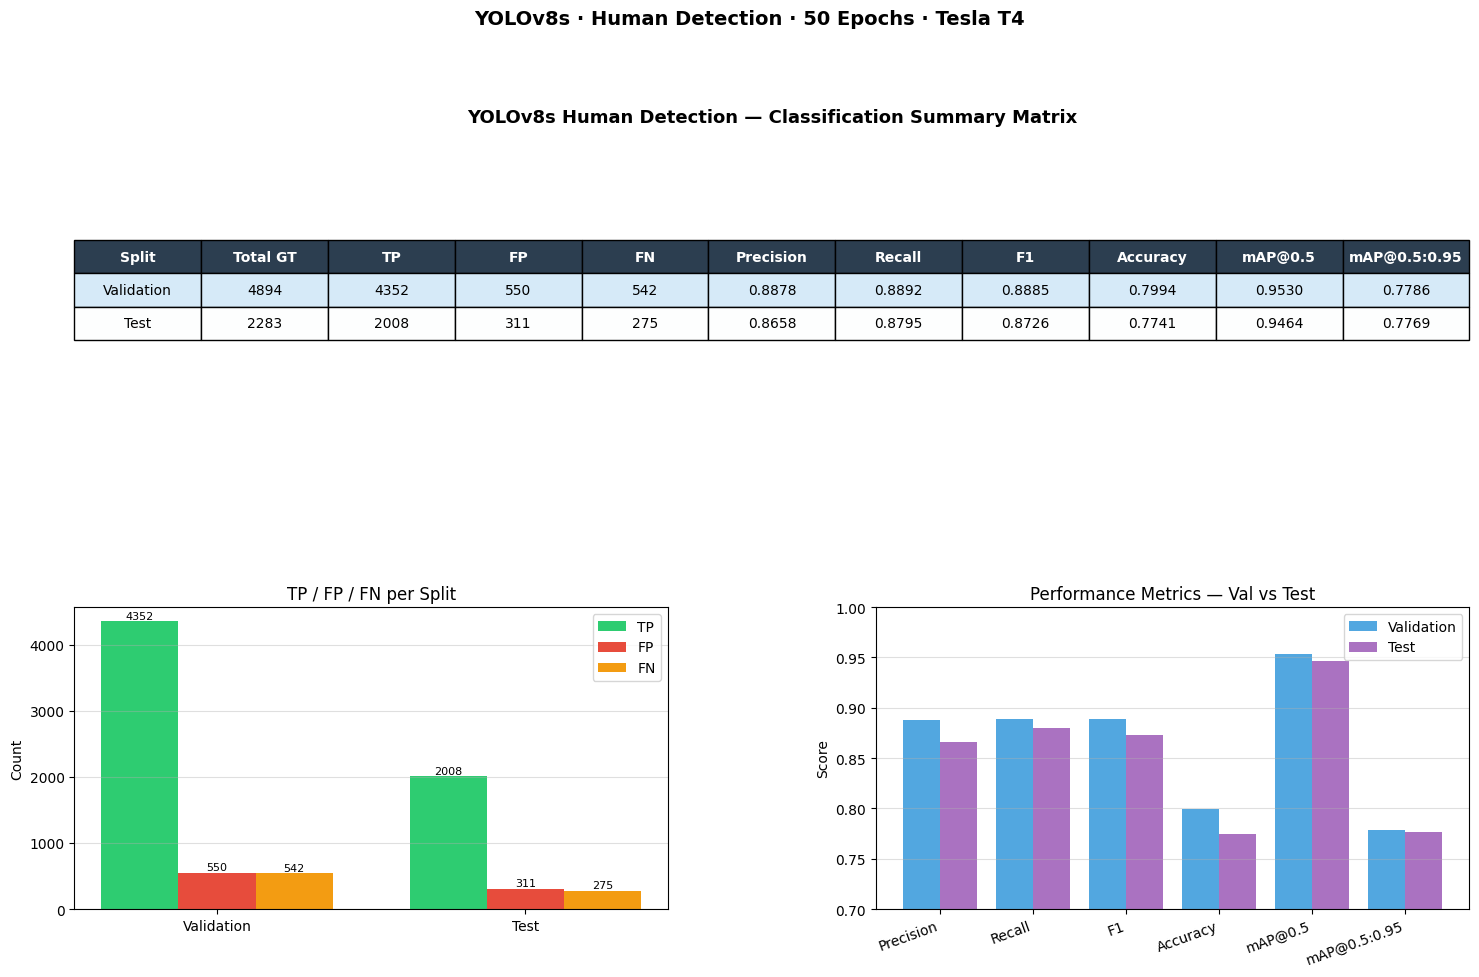


✅ Figure saved as yolov8s_classification_matrix.png


  📊 Validation Results
  Total GT            : 4894
  TP / FP / FN        : 4352 / 550 / 542
  Precision           : 0.8878
  Recall              : 0.8892
  F1 Score            : 0.8885
  Accuracy            : 0.7994
  mAP@0.5             : 0.9530
  mAP@0.5:0.95        : 0.7786

  📊 Test Results
  Total GT            : 2283
  TP / FP / FN        : 2008 / 311 / 275
  Precision           : 0.8658
  Recall              : 0.8795
  F1 Score            : 0.8726
  Accuracy            : 0.7741
  mAP@0.5             : 0.9464
  mAP@0.5:0.95        : 0.7769



In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec

# ── Metrics from your training log ──────────────────────────────────────────
results = {
    "Validation": {"P": 0.8878, "R": 0.8892, "mAP50": 0.9530, "mAP50_95": 0.7786},
    "Test":       {"P": 0.8658, "R": 0.8795, "mAP50": 0.9464, "mAP50_95": 0.7769},
}

# Total instances per split
instances = {"Validation": 4894, "Test": 2283}

# ── Derive TP / FP / FN from P, R, total instances ──────────────────────────
def derive_counts(P, R, total_instances):
    """
    TP / (TP + FN) = R  →  TP = R * total_instances  (approx)
    TP / (TP + FP) = P  →  FP = TP * (1/P - 1)
    FN = total_instances - TP
    """
    TP = round(R * total_instances)
    FP = round(TP * (1 / P - 1))
    FN = total_instances - TP
    TN = 0   # single-class detection — TN is background (not directly tracked)
    return TP, FP, FN, TN

# ── Accuracy (detection accuracy) = TP / (TP + FP + FN) ────────────────────
def detection_accuracy(TP, FP, FN):
    return TP / (TP + FP + FN)

# ── F1 Score ─────────────────────────────────────────────────────────────────
def f1(P, R):
    return 2 * P * R / (P + R)

# ── Build summary table data ─────────────────────────────────────────────────
rows = []
for split, m in results.items():
    P, R = m["P"], m["R"]
    N    = instances[split]
    TP, FP, FN, _ = derive_counts(P, R, N)
    acc  = detection_accuracy(TP, FP, FN)
    F1   = f1(P, R)
    rows.append([split, N, TP, FP, FN,
                 f"{P:.4f}", f"{R:.4f}", f"{F1:.4f}",
                 f"{acc:.4f}", f"{m['mAP50']:.4f}", f"{m['mAP50_95']:.4f}"])

cols = ["Split", "Total GT", "TP", "FP", "FN",
        "Precision", "Recall", "F1", "Accuracy", "mAP@0.5", "mAP@0.5:0.95"]

# ── Plot ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 10))
gs  = GridSpec(2, 2, figure=fig, hspace=0.55, wspace=0.35)

# --- 1. Summary Table --------------------------------------------------------
ax_tbl = fig.add_subplot(gs[0, :])
ax_tbl.axis("off")
tbl = ax_tbl.table(
    cellText=rows,
    colLabels=cols,
    loc="center",
    cellLoc="center"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 2.0)

# Header styling
for j in range(len(cols)):
    tbl[0, j].set_facecolor("#2c3e50")
    tbl[0, j].set_text_props(color="white", fontweight="bold")

# Row colouring
row_colors = ["#d6eaf8", "#fdfefe"]
for i, row in enumerate(rows):
    for j in range(len(cols)):
        tbl[i+1, j].set_facecolor(row_colors[i % 2])

ax_tbl.set_title("YOLOv8s Human Detection — Classification Summary Matrix",
                 fontsize=13, fontweight="bold", pad=12)

# --- 2. Confusion-style bar chart (TP / FP / FN) ----------------------------
ax_bar = fig.add_subplot(gs[1, 0])
splits = [r[0] for r in rows]
TPs = [r[2] for r in rows]
FPs = [r[3] for r in rows]
FNs = [r[4] for r in rows]

x   = np.arange(len(splits))
w   = 0.25
ax_bar.bar(x - w,  TPs, w, label="TP", color="#2ecc71")
ax_bar.bar(x,      FPs, w, label="FP", color="#e74c3c")
ax_bar.bar(x + w,  FNs, w, label="FN", color="#f39c12")
ax_bar.set_xticks(x); ax_bar.set_xticklabels(splits)
ax_bar.set_ylabel("Count"); ax_bar.set_title("TP / FP / FN per Split")
ax_bar.legend(); ax_bar.grid(axis="y", alpha=0.4)

for bar in ax_bar.patches:
    h = bar.get_height()
    ax_bar.text(bar.get_x() + bar.get_width()/2, h + 10,
                str(int(h)), ha="center", va="bottom", fontsize=8)

# --- 3. Metric comparison radar / bar ----------------------------------------
ax_met = fig.add_subplot(gs[1, 1])
metric_labels = ["Precision", "Recall", "F1", "Accuracy", "mAP@0.5", "mAP@0.5:0.95"]

val_vals  = [float(rows[0][5]), float(rows[0][6]), float(rows[0][7]),
             float(rows[0][8]), float(rows[0][9]), float(rows[0][10])]
test_vals = [float(rows[1][5]), float(rows[1][6]), float(rows[1][7]),
             float(rows[1][8]), float(rows[1][9]), float(rows[1][10])]

x2 = np.arange(len(metric_labels))
ax_met.bar(x2 - 0.2, val_vals,  0.4, label="Validation", color="#3498db", alpha=0.85)
ax_met.bar(x2 + 0.2, test_vals, 0.4, label="Test",       color="#9b59b6", alpha=0.85)
ax_met.set_xticks(x2); ax_met.set_xticklabels(metric_labels, rotation=20, ha="right")
ax_met.set_ylim(0.70, 1.00); ax_met.set_ylabel("Score")
ax_met.set_title("Performance Metrics — Val vs Test")
ax_met.legend(); ax_met.grid(axis="y", alpha=0.4)

plt.suptitle("YOLOv8s · Human Detection · 50 Epochs · Tesla T4",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig("yolov8s_classification_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Figure saved as yolov8s_classification_matrix.png")

# ── Print clean console summary ───────────────────────────────────────────────
print("\n" + "="*55)
for r in rows:
    split = r[0]
    print(f"\n  📊 {split} Results")
    print(f"  {'Total GT':<20}: {r[1]}")
    print(f"  {'TP / FP / FN':<20}: {r[2]} / {r[3]} / {r[4]}")
    print(f"  {'Precision':<20}: {r[5]}")
    print(f"  {'Recall':<20}: {r[6]}")
    print(f"  {'F1 Score':<20}: {r[7]}")
    print(f"  {'Accuracy':<20}: {r[8]}")
    print(f"  {'mAP@0.5':<20}: {r[9]}")
    print(f"  {'mAP@0.5:0.95':<20}: {r[10]}")
print("\n" + "="*55)

In [ ]:
!pip install ultralytics

from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Your trained model
model = YOLO('/content/drive/MyDrive/MainProject/runs/detect/human_detection/yolov8s_run1/weights/best.pt')
print("✅ Model loaded successfully!")
print(f"   Model: YOLOv8s | Classes: {model.names}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 27.6 MB/s eta 0:00:00
Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Model loaded successfully!
   Model: YOLOv8s | Classes: {0: 'person'}


Saving DSC_0405.JPG to DSC_0405.JPG

image 1/1 /content/fixed_DSC_0405.JPG: 640x448 6 persons, 72.6ms
Speed: 12.9ms preprocess, 72.6ms inference, 42.1ms postprocess per image at shape (1, 3, 640, 448)


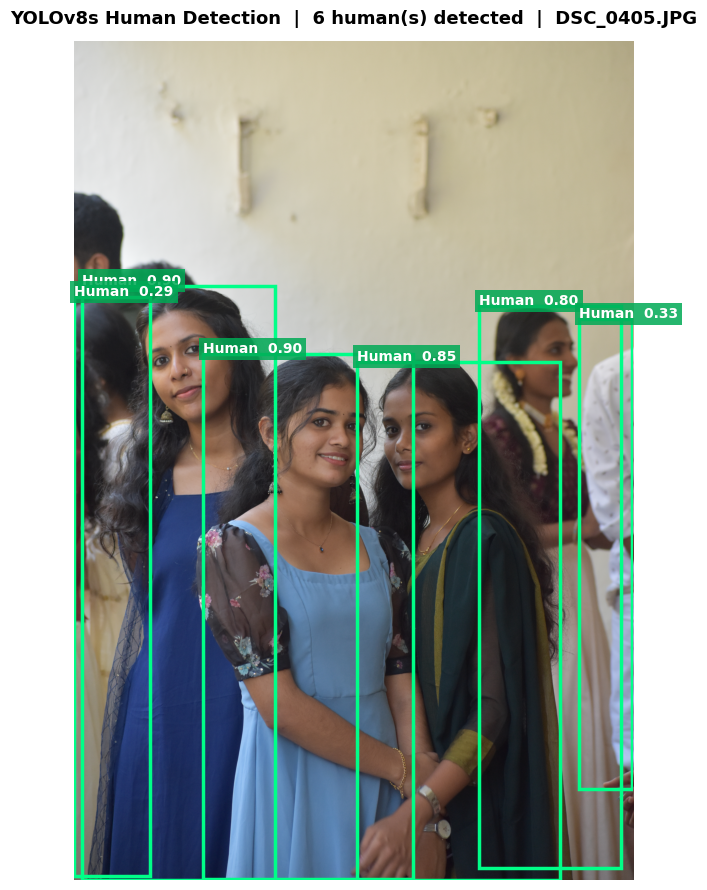


  📷 Image    : DSC_0405.JPG
  👤 Detected : 6 human(s)
  Person 1  →  conf: 0.8955
  Person 2  →  conf: 0.8951
  Person 3  →  conf: 0.8517
  Person 4  →  conf: 0.7978
  Person 5  →  conf: 0.3266
  Person 6  →  conf: 0.2870
  💾 Saved → /content/detected_DSC_0405.JPG


In [ ]:
from google.colab import files
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

# Upload image
uploaded = files.upload()

for filename in uploaded.keys():
    img_path = f'/content/{filename}'

    # ── Fix EXIF orientation BEFORE passing to model ──────────────────────
    img_pil = Image.open(img_path)
    img_pil = ImageOps.exif_transpose(img_pil)   # 👈 this fixes the rotation
    img_pil.save(f'/content/fixed_{filename}')    # save corrected version
    fixed_path = f'/content/fixed_{filename}'

    # ── Run inference on corrected image ──────────────────────────────────
    results = model.predict(
        source=fixed_path,
        conf=0.25,
        iou=0.7,
        imgsz=640,
    )

    result = results[0]
    total  = len(result.boxes)

    # ── Plot ──────────────────────────────────────────────────────────────
    img_np = np.array(img_pil)
    fig, ax = plt.subplots(figsize=(14, 9))
    ax.imshow(img_np)

    for box in result.boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf_score      = box.conf[0].item()

        rect = patches.Rectangle(
            (x1, y1), x2 - x1, y2 - y1,
            linewidth=2.5,
            edgecolor='#00ff88',
            facecolor='none'
        )
        ax.add_patch(rect)
        ax.text(
            x1, y1 - 8,
            f"Human  {conf_score:.2f}",
            color='white', fontsize=10, fontweight='bold',
            bbox=dict(facecolor='#00aa55', alpha=0.85, pad=3, edgecolor='none')
        )

    ax.set_title(
        f"YOLOv8s Human Detection  |  {total} human(s) detected  |  {filename}",
        fontsize=13, fontweight='bold', pad=12
    )
    ax.axis('off')
    plt.tight_layout()
    plt.savefig(f'/content/detected_{filename}', dpi=150, bbox_inches='tight')
    plt.show()

    print(f"\n{'='*45}")
    print(f"  📷 Image    : {filename}")
    print(f"  👤 Detected : {total} human(s)")
    for i, box in enumerate(result.boxes):
        print(f"  Person {i+1}  →  conf: {box.conf[0].item():.4f}")
    print(f"  💾 Saved → /content/detected_{filename}")
    print(f"{'='*45}")

In [ ]:
!pip install -q numpy==1.26.4
!pip install -q albumentations==1.3.1
!pip install -q insightface==0.7.3 --no-deps
!pip install facenet-pytorch onnxruntime-gpu -q

from ultralytics import YOLO
from facenet_pytorch import MTCNN
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch
import os

print("✅ All libraries loaded!")

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
insightface 0.7.3 requires onnx, which is not installed.
ultralytics-thop 2.0.18 requires torch, which is not installed.
ultralytics 8.4.21 requires torch>=1.8.0, which is not installed.
peft 0.18.1 requires torch>=1.13.0, which is not installed.
fastai 2.8.7 requires torch<3,>=1.10, which is not installed.
accelerate 1.13.0 requires torch>=2.0.0, which is not installed.
sentence-transformers 5.2.3 requires torch>=1.11.0, which is not installed.
torchvision 0.25.0+cu128 requires torch==2.10.0, which is not installed.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.3 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.3 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behav

In [ ]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️  Running on: {device}")

# ── Load YOLOv8s (your trained model) ────────────────────────────────────────
yolo_model = YOLO('/content/drive/MyDrive/MainProject/runs/detect/human_detection/yolov8s_run1/weights/best.pt')

# ── Load MTCNN ────────────────────────────────────────────────────────────────
mtcnn = MTCNN(
    keep_all=True,          # detect ALL faces in the crop
    device=device,
    min_face_size=20,       # minimum face size in pixels
    thresholds=[0.6, 0.7, 0.8],   # P-Net, R-Net, O-Net thresholds
    post_process=False,
)

# ── Save MTCNN weights locally for edge use ───────────────────────────────────
os.makedirs('/content/drive/MyDrive/MainProject/runs/faceCrop/models/mtcnn', exist_ok=True)

torch.save(mtcnn.pnet.state_dict(),  '/content/drive/MyDrive/MainProject/runs/faceCrop/models/mtcnn/pnet.pt')
torch.save(mtcnn.rnet.state_dict(),  '/content/drive/MyDrive/MainProject/runs/faceCrop/models/mtcnn/rnet.pt')
torch.save(mtcnn.onet.state_dict(),  '/content/drive/MyDrive/MainProject/runs/faceCrop/models/mtcnn/onet.pt')

# ── Also copy YOLO weights to same folder ────────────────────────────────────
import shutil
shutil.copy(
    '/content/drive/MyDrive/MainProject/runs/detect/human_detection/yolov8s_run1/weights/best.pt',
    '/content/drive/MyDrive/MainProject/yolov8s.pt'
)

print("✅ Both models saved to /content/models/")
print("   ├── yolov8s_human.pt")
print("   ├── mtcnn/pnet.pt")
print("   ├── mtcnn/rnet.pt")
print("   └── mtcnn/onet.pt")

🖥️  Running on: cuda
✅ Both models saved to /content/models/
   ├── yolov8s_human.pt
   ├── mtcnn/pnet.pt
   ├── mtcnn/rnet.pt
   └── mtcnn/onet.pt


🖥️  Running on: cuda
✅ MTCNN weights saved to Drive


Saving DSC_0357.JPG to DSC_0357.JPG

  📷 Processing: DSC_0357.JPG

  👤 2 human(s) detected by YOLOv8s


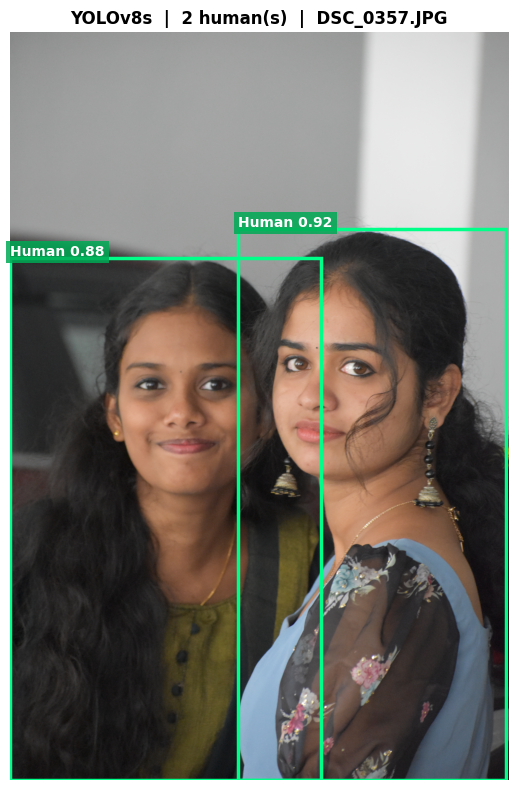

  ✅ Person 1 → face saved → /content/faces/face_1.png
  ✅ Person 2 → face saved → /content/faces/face_2.png


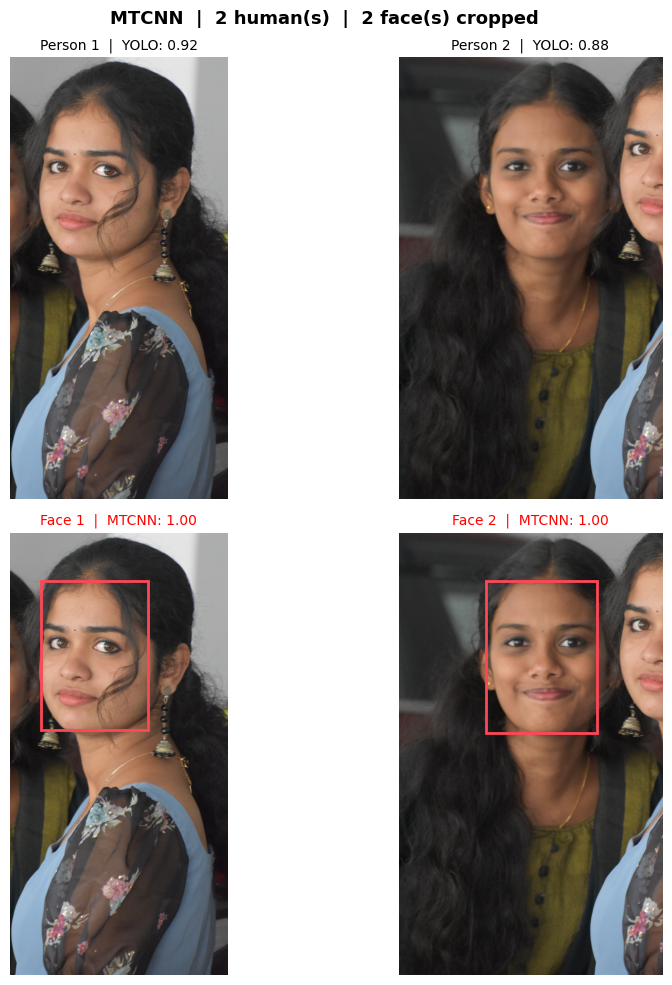


  📷 Image  : DSC_0357.JPG
  👤 Humans : 2
  😊 Faces  : 2 → /content/faces/

✅ Done — 2 face(s) ready in cropped_faces[]


In [ ]:
from google.colab import files
from ultralytics import YOLO
from facenet_pytorch import MTCNN
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import torch
import os

# ── Device ────────────────────────────────────────────────────────────────────
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"🖥️  Running on: {device}")

# ── Load Models ───────────────────────────────────────────────────────────────
yolo_model = YOLO('/content/drive/MyDrive/MainProject/runs/detect/human_detection/yolov8s_run1/weights/best.pt')

mtcnn = MTCNN(
    keep_all=True,
    device=device,
    min_face_size=20,
    thresholds=[0.6, 0.7, 0.8],
    post_process=False,
)

# ── Save MTCNN weights to Drive ───────────────────────────────────────────────
os.makedirs('/content/drive/MyDrive/MainProject/runs/faceCrop/models/mtcnn', exist_ok=True)
torch.save(mtcnn.pnet.state_dict(), '/content/drive/MyDrive/MainProject/runs/faceCrop/models/mtcnn/pnet.pt')
torch.save(mtcnn.rnet.state_dict(), '/content/drive/MyDrive/MainProject/runs/faceCrop/models/mtcnn/rnet.pt')
torch.save(mtcnn.onet.state_dict(), '/content/drive/MyDrive/MainProject/runs/faceCrop/models/mtcnn/onet.pt')
print("✅ MTCNN weights saved to Drive")

# ── Output folders ────────────────────────────────────────────────────────────
os.makedirs('/content/faces', exist_ok=True)
cropped_faces = []  # ← use this in next cells

# ── Upload ────────────────────────────────────────────────────────────────────
uploaded = files.upload()

for filename in uploaded.keys():
    print(f"\n{'='*55}")
    print(f"  📷 Processing: {filename}")
    print(f"{'='*55}")

    # ── Open + fix EXIF + resize large images ─────────────────────────────────
    img_pil = ImageOps.exif_transpose(Image.open(f'/content/{filename}'))
    if max(img_pil.size) > 3000:
        img_pil.thumbnail((3000, 3000), Image.BILINEAR)
    img_np = np.array(img_pil)

    # ── YOLO → detect humans ──────────────────────────────────────────────────
    yolo_results = yolo_model.predict(source=img_pil, conf=0.25, iou=0.7,
                                      imgsz=640, device=device, verbose=False)
    human_boxes = yolo_results[0].boxes
    print(f"\n  👤 {len(human_boxes)} human(s) detected by YOLOv8s")

    # ── Show YOLO detections on full image ────────────────────────────────────
    fig1, ax1 = plt.subplots(figsize=(12, 8))
    ax1.imshow(img_np)
    for box in human_boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        conf_score      = box.conf[0].item()
        ax1.add_patch(patches.Rectangle(
            (x1, y1), x2-x1, y2-y1,
            linewidth=2.5, edgecolor='#00ff88', facecolor='none'
        ))
        ax1.text(x1, y1-8, f"Human {conf_score:.2f}",
                 color='white', fontsize=10, fontweight='bold',
                 bbox=dict(facecolor='#00aa55', alpha=0.85, pad=3, edgecolor='none'))
    ax1.set_title(f"YOLOv8s  |  {len(human_boxes)} human(s)  |  {filename}",
                  fontsize=12, fontweight='bold')
    ax1.axis('off')
    plt.tight_layout()
    plt.show()
    plt.close()

    # ── MTCNN → crop face from each human ────────────────────────────────────
    all_faces = []
    fig2, axes = plt.subplots(2, max(len(human_boxes), 1), figsize=(5 * max(len(human_boxes), 1), 10))
    if len(human_boxes) == 1:
        axes = np.array(axes).reshape(2, 1)

    for i, box in enumerate(human_boxes):
        x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]
        conf_yolo       = box.conf[0].item()

        pad        = 10
        human_crop = img_pil.crop((
            max(0, x1-pad), max(0, y1-pad),
            min(img_np.shape[1], x2+pad),
            min(img_np.shape[0], y2+pad)
        ))
        human_crop_np = np.array(human_crop)

        # Top row → human crop
        axes[0][i].imshow(human_crop_np)
        axes[0][i].set_title(f"Person {i+1}  |  YOLO: {conf_yolo:.2f}", fontsize=10)
        axes[0][i].axis('off')

        # MTCNN → detect face
        face_boxes, probs = mtcnn.detect(human_crop)

        if face_boxes is not None:
            best               = np.argmax(probs)
            fx1, fy1, fx2, fy2 = [int(v) for v in face_boxes[best]]
            fx1 = max(0, fx1);  fy1 = max(0, fy1)
            fx2 = min(human_crop.width,  fx2)
            fy2 = min(human_crop.height, fy2)

            face_crop = human_crop.crop((fx1, fy1, fx2, fy2)).resize((160, 160))
            face_crop.save(f'/content/faces/face_{i+1}.png')
            all_faces.append(face_crop)
            cropped_faces.append(face_crop)  # ← for next cells

            # Bottom row → human crop + face box
            axes[1][i].imshow(human_crop_np)
            axes[1][i].add_patch(patches.Rectangle(
                (fx1, fy1), fx2-fx1, fy2-fy1,
                linewidth=2, edgecolor='#ff4757', facecolor='none'
            ))
            axes[1][i].set_title(f"Face {i+1}  |  MTCNN: {probs[best]:.2f}",
                                  fontsize=10, color='red')
            axes[1][i].axis('off')
            print(f"  ✅ Person {i+1} → face saved → /content/faces/face_{i+1}.png")
        else:
            axes[1][i].imshow(human_crop_np)
            axes[1][i].set_title(f"Person {i+1}  |  No face", fontsize=10, color='gray')
            axes[1][i].axis('off')
            print(f"  ⚠️  Person {i+1} → no face detected")

    fig2.suptitle(
        f"MTCNN  |  {len(human_boxes)} human(s)  |  {len(all_faces)} face(s) cropped",
        fontsize=13, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()
    plt.close()

    print(f"\n{'='*55}")
    print(f"  📷 Image  : {filename}")
    print(f"  👤 Humans : {len(human_boxes)}")
    print(f"  😊 Faces  : {len(all_faces)} → /content/faces/")
    print(f"{'='*55}")

print(f"\n✅ Done — {len(cropped_faces)} face(s) ready in cropped_faces[]")

In [ ]:
import os, sqlite3, json, warnings, io
from datetime import datetime
from google.colab import files

import numpy as np
import torch
import onnxruntime as ort
from PIL import Image, ImageOps
from facenet_pytorch import MTCNN
from facenet_pytorch.models.mtcnn import PNet, RNet, ONet

warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"[INFO] Device : {DEVICE.upper()}")

DB_PATH   = "/content/face_database.db"
JSON_PATH = "/content/face_database.json"

[INFO] Device : CUDA


In [ ]:
PNET_W = "/content/drive/MyDrive/MainProject/runs/faceCrop/models/mtcnn/pnet.pt"
RNET_W = "/content/drive/MyDrive/MainProject/runs/faceCrop/models/mtcnn/rnet.pt"
ONET_W = "/content/drive/MyDrive/MainProject/runs/faceCrop/models/mtcnn/onet.pt"

print("[INFO] Loading MTCNN ...")
pnet = PNet().to(DEVICE)
rnet = RNet().to(DEVICE)
onet = ONet().to(DEVICE)

pnet.load_state_dict(torch.load(PNET_W, map_location=DEVICE))
rnet.load_state_dict(torch.load(RNET_W, map_location=DEVICE))
onet.load_state_dict(torch.load(ONET_W, map_location=DEVICE))
pnet.eval(); rnet.eval(); onet.eval()

mtcnn = MTCNN(keep_all=True, device=DEVICE,
              min_face_size=20, thresholds=[0.6, 0.7, 0.8],
              post_process=False)
mtcnn.pnet = pnet
mtcnn.rnet = rnet
mtcnn.onet = onet
print("[INFO] MTCNN ready ✓")

[INFO] Loading MTCNN ...
[INFO] MTCNN ready ✓


In [ ]:
ARCFACE_PATH = "/content/w600k_r50.onnx"

if not os.path.exists(ARCFACE_PATH):
    print("[INFO] Downloading ArcFace ONNX model ...")
    import urllib.request
    urllib.request.urlretrieve(
        "https://github.com/deepinsight/insightface/releases/download/v0.7/buffalo_l.zip",
        "/content/buffalo_l.zip"
    )
    import zipfile
    with zipfile.ZipFile("/content/buffalo_l.zip", "r") as z:
        z.extractall("/content/buffalo_l")
    # find the recognition onnx
    for root, dirs, fnames in os.walk("/content/buffalo_l"):
        for f in fnames:
            if f.endswith(".onnx") and "rec" in f.lower() or "r50" in f.lower() or "w600" in f.lower():
                import shutil
                shutil.copy(os.path.join(root, f), ARCFACE_PATH)
                print(f"[INFO] Found model: {f}")
                break

# providers = ["CUDAExecutionProvider"] if DEVICE == "cuda" else ["CPUExecutionProvider"]
providers = ["CPUExecutionProvider"]
arcface_session = ort.InferenceSession(ARCFACE_PATH, providers=providers)
arcface_input   = arcface_session.get_inputs()[0].name
print("[INFO] ArcFace ready ✓")

[INFO] ArcFace ready ✓


In [ ]:
def get_embedding(pil_img):
    img = pil_img.convert("RGB").resize((112, 112), Image.BILINEAR)
    bgr = np.array(img)[:, :, ::-1].astype(np.float32)
    # normalize to [-1, 1]
    bgr = (bgr - 127.5) / 127.5
    inp = np.transpose(bgr, (2, 0, 1))[np.newaxis]  # (1, 3, 112, 112)
    try:
        feat = arcface_session.run(None, {arcface_input: inp})[0][0]
        feat = feat.astype(np.float32)
        norm = np.linalg.norm(feat)
        return feat / norm if norm > 0 else feat
    except Exception as e:
        print(f"  [WARN] Embedding failed: {e}")
        return None

def crop_face(pil_img):
    boxes, probs = mtcnn.detect(pil_img)
    if boxes is not None:
        idx          = int(np.argmax(probs))
        x1, y1, x2, y2 = [int(v) for v in boxes[idx]]
        x1 = max(0, x1); y1 = max(0, y1)
        x2 = min(pil_img.width, x2)
        y2 = min(pil_img.height, y2)
        return pil_img.crop((x1, y1, x2, y2)).resize((160, 160), Image.BILINEAR)
    else:
        return pil_img.resize((160, 160), Image.BILINEAR)

In [ ]:
def get_db():
    conn = sqlite3.connect(DB_PATH, check_same_thread=False)
    conn.executescript("""
        CREATE TABLE IF NOT EXISTS persons (
            id              INTEGER PRIMARY KEY AUTOINCREMENT,
            person_id       TEXT    UNIQUE NOT NULL,
            name            TEXT    NOT NULL,
            role            TEXT,
            department      TEXT,
            access_level    TEXT,
            date_registered TEXT
        );
        CREATE TABLE IF NOT EXISTS embeddings (
            id           INTEGER PRIMARY KEY AUTOINCREMENT,
            person_id    INTEGER NOT NULL REFERENCES persons(id),
            embedding    BLOB    NOT NULL,
            source_image TEXT,
            created_at   TEXT
        );
        CREATE INDEX IF NOT EXISTS idx_person_id ON embeddings(person_id);
    """)
    conn.commit()
    return conn

def insert_person(conn, person_id, name, role, department, access_level):
    cur = conn.cursor()
    try:
        cur.execute("""
            INSERT INTO persons
                (person_id, name, role, department, access_level, date_registered)
            VALUES (?, ?, ?, ?, ?, ?)
        """, (person_id, name, role, department,
              access_level, datetime.now().isoformat()))
        conn.commit()
        pid = cur.lastrowid
        print(f"[DB] Inserted '{name}'  (row={pid})")
        return pid
    except sqlite3.IntegrityError:
        cur.execute("SELECT id FROM persons WHERE person_id=?", (person_id,))
        pid = cur.fetchone()[0]
        print(f"[DB] '{name}' already exists — appending embeddings")
        return pid

def insert_embedding(conn, person_id, vec, source=""):
    conn.execute("""
        INSERT INTO embeddings (person_id, embedding, source_image, created_at)
        VALUES (?, ?, ?, ?)
    """, (person_id, vec.astype(np.float32).tobytes(),
          source, datetime.now().isoformat()))
    conn.commit()

def export_json(conn):
    cur = conn.cursor()
    cur.execute("""
        SELECT p.id, p.person_id, p.name, p.role,
               p.department, p.access_level, e.embedding
        FROM persons p JOIN embeddings e ON e.person_id = p.id
    """)
    out = {}
    for pid, eid, name, role, dept, access, blob in cur.fetchall():
        vec = np.frombuffer(blob, dtype=np.float32).tolist()
        if str(pid) not in out:
            out[str(pid)] = {
                "meta": {"person_id": eid, "name": name, "role": role,
                         "department": dept, "access_level": access},
                "embeddings": []
            }
        out[str(pid)]["embeddings"].append(vec)
    with open(JSON_PATH, "w") as f:
        json.dump(out, f, indent=2)
    print(f"[DB] JSON saved → {JSON_PATH}")

In [ ]:
def register_person_colab():
    print("\n" + "="*55)
    print("  PERSON REGISTRATION")
    print("="*55)

    # ── Step 1: person details ────────────────────────────
    PERSON_ID    = input("Person ID       : ").strip()
    NAME         = input("Full Name       : ").strip()
    ROLE         = input("Role            : ").strip()
    DEPARTMENT   = input("Department      : ").strip()
    ACCESS_LEVEL = input("Access Level (admin/standard/restricted) [standard]: ").strip() or "standard"

    if not PERSON_ID or not NAME:
        print("[REG] Person ID and Name are required.")
        return

    print(f"\n[REG] Registering: {NAME} ({PERSON_ID})")

    # ── Step 2: upload existing DB if available ───────────
    load_existing = input("Do you have an existing face_database.db to load? (y/n): ").strip().lower()
    if load_existing == 'y':
        print("Upload your face_database.db:")
        existing = files.upload()
        if 'face_database.db' in existing:
            with open(DB_PATH, 'wb') as f:
                f.write(existing['face_database.db'])
            print("[DB] Existing database loaded ✓")
    else:
        print("[DB] Starting fresh database")

    # ── Step 3: upload reference images ──────────────────
    print(f"\nUpload 10+ reference images for {NAME}:")
    uploaded_imgs = files.upload()

    if not uploaded_imgs:
        print("[REG] No images uploaded.")
        return

    print(f"[REG] {len(uploaded_imgs)} image(s) uploaded")

    # ── Step 4: process → face crop → embedding ──────────
    face_vecs = []
    for fname, fbytes in uploaded_imgs.items():
        try:
            pil  = ImageOps.exif_transpose(Image.open(io.BytesIO(fbytes)).convert("RGB"))
            face = crop_face(pil)
            vec  = get_embedding(face)
            if vec is not None:
                face_vecs.append((vec, fname))
                print(f"  ✅ {fname}")
            else:
                print(f"  ⚠️  {fname} — embedding failed")
        except Exception as e:
            print(f"  ❌ {fname} — {e}")

    if not face_vecs:
        print("[REG] No valid embeddings. Aborting.")
        return

    # ── Step 5: save to DB ────────────────────────────────
    conn = get_db()
    pid  = insert_person(conn, PERSON_ID, NAME, ROLE, DEPARTMENT, ACCESS_LEVEL)

    for vec, path in face_vecs:
        insert_embedding(conn, pid, vec, path)

    # aggregate embedding
    all_vecs = np.stack([v for v, _ in face_vecs])
    agg      = all_vecs.mean(axis=0)
    norm     = np.linalg.norm(agg)
    agg      = agg / norm if norm > 0 else agg
    insert_embedding(conn, pid, agg, "AGGREGATE")

    export_json(conn)
    conn.close()

    print(f"\n[REG] Done ✓")
    print(f"  Name        : {NAME}")
    print(f"  Person ID   : {PERSON_ID}")
    print(f"  Embeddings  : {len(face_vecs)} individual + 1 aggregate")

    # ── Step 6: download DB + JSON ────────────────────────
    print("\n[REG] Downloading files ...")
    files.download(DB_PATH)
    files.download(JSON_PATH)

    again = input("\nRegister another person? (y/n): ").strip().lower()
    if again == 'y':
        register_person_colab()

In [ ]:
register_person_colab()


  PERSON REGISTRATION
Person ID       : 1
Full Name       : moggerlal
Role            : actor
Department      : cinema
Access Level (admin/standard/restricted) [standard]: standard

[REG] Registering: moggerlal (1)
Do you have an existing face_database.db to load? (y/n): n
[DB] Starting fresh database

Upload 10+ reference images for moggerlal:


Saving Mohanlal.jpg to Mohanlal.jpg
Saving images (6).jpg to images (6).jpg
Saving download.jpg to download (1).jpg
Saving images (5).jpg to images (5) (1).jpg
Saving images (4).jpg to images (4) (1).jpg
Saving images (3).jpg to images (3) (1).jpg
Saving images (2).jpg to images (2) (1).jpg
Saving images (1).jpg to images (1) (2).jpg
Saving images.jpg to images (7).jpg
Saving c6915bffacfe0a7fa43ba0314f704887.jpg to c6915bffacfe0a7fa43ba0314f704887 (1).jpg
Saving Mohanlal-photo-0126092025.jpg to Mohanlal-photo-0126092025 (1).jpg
[REG] 11 image(s) uploaded
  ✅ Mohanlal.jpg
  ✅ images (6).jpg
  ✅ download (1).jpg
  ✅ images (5) (1).jpg
  ✅ images (4) (1).jpg
  ✅ images (3) (1).jpg
  ✅ images (2) (1).jpg
  ✅ images (1) (2).jpg
  ✅ images (7).jpg
  ✅ c6915bffacfe0a7fa43ba0314f704887 (1).jpg
  ✅ Mohanlal-photo-0126092025 (1).jpg
[DB] Inserted 'moggerlal'  (row=1)
[DB] JSON saved → /content/face_database.json

[REG] Done ✓
  Name        : moggerlal
  Person ID   : 1
  Embeddings  : 11 individ

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


Register another person? (y/n): n


[INFO] Device : CUDA
[DB] Found ✓ → /content/face_database.db
[ArcFace] Ready ✓
[INFO] Loading YOLO ...
[INFO] Loading MTCNN ...
[DB] Connected ✓
[DB] Loaded 1 person(s)
[INFO] All models ready ✓
Upload image to identify:


Saving test image.jpg to test image (4).jpg

  📷 test image (4).jpg
  👤 1 human(s) detected


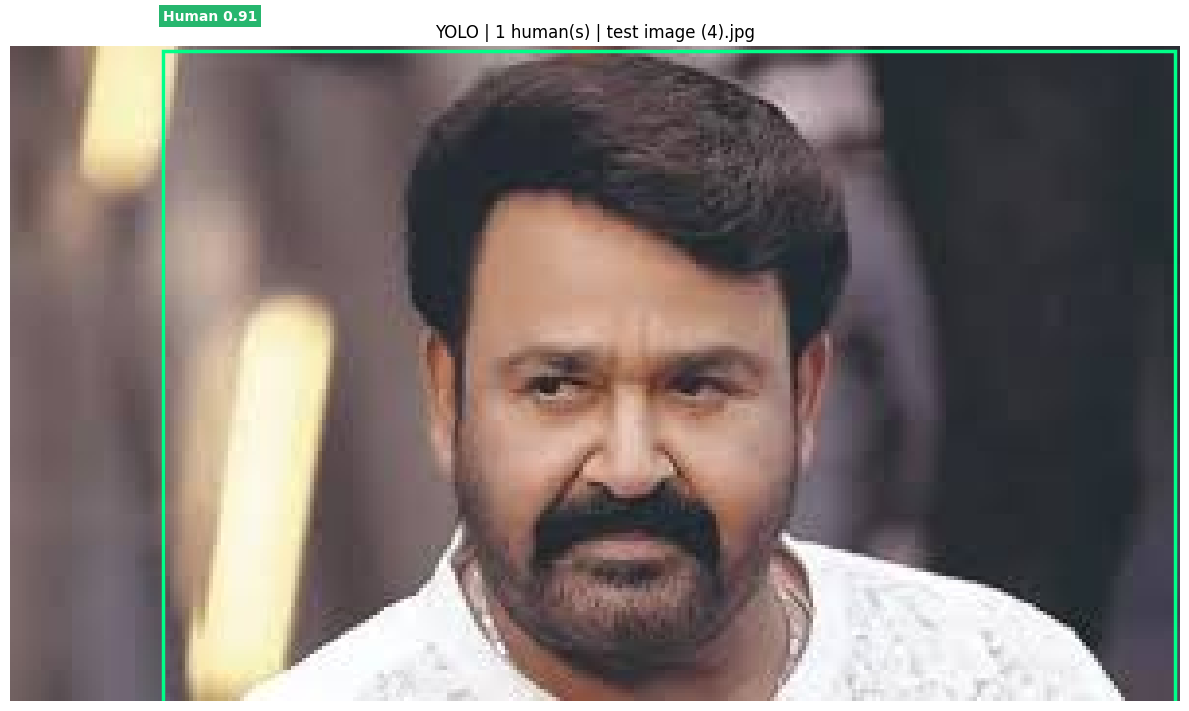

  [DEBUG] vec is None: False
  [DEBUG] db_cache keys: [1]
  ✓ MATCH  moggerlal            cos=0.750  euc=0.71


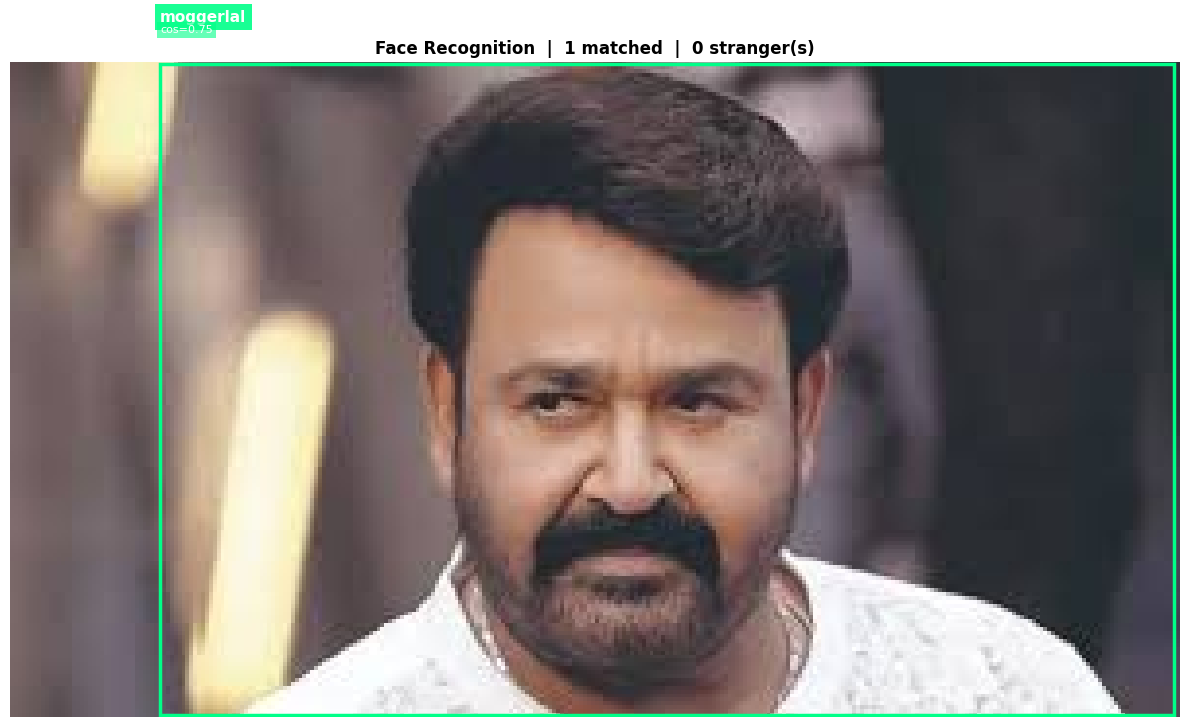


  📷 Image   : test image (4).jpg
  👤 Humans  : 1
  😊 Faces   : 1
  🔍 Matched : 1 / 1
  ⏱  Time    : 0.78s

  ── Person 1 ──────────────────────────────
  ✅ MATCHED
     Name         : moggerlal
     Person ID    : 1
     Role         : actor
     Department   : cinema
     Access Level : standard
     Cosine Score : 0.7502
     Euclidean    : 0.7069
     Match Method : both



In [ ]:
# ============================================================
#  CELL 1 — Imports & Config
# ============================================================
import os, json, sqlite3, time, warnings, io
from datetime import datetime
from google.colab import files

import numpy as np
import torch
import onnxruntime as ort
from PIL import Image, ImageOps
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from ultralytics import YOLO
from facenet_pytorch import MTCNN
from facenet_pytorch.models.mtcnn import PNet, RNet, ONet

warnings.filterwarnings("ignore")

class Config:
    YOLO_WEIGHTS  = "/content/drive/MyDrive/MainProject/runs/detect/human_detection/yolov8s_run1/weights/best.pt"
    PNET_WEIGHTS  = "/content/drive/MyDrive/MainProject/runs/faceCrop/models/mtcnn/pnet.pt"
    RNET_WEIGHTS  = "/content/drive/MyDrive/MainProject/runs/faceCrop/models/mtcnn/rnet.pt"
    ONET_WEIGHTS  = "/content/drive/MyDrive/MainProject/runs/faceCrop/models/mtcnn/onet.pt"
    ARCFACE_PATH  = "/content/w600k_r50.onnx"
    DB_PATH       = "/content/face_database.db"
    JSON_PATH     = "/content/face_database.json"
    OUTPUT_DIR    = "/content/output"
    MIN_FACE_SIZE = 20
    THRESHOLDS    = [0.6, 0.7, 0.8]
    PADDING       = 10
    YOLO_CONF     = 0.25
    YOLO_IOU      = 0.7
    YOLO_IMGSZ    = 640
    COSINE_THRESHOLD    = 0.45
    EUCLIDEAN_THRESHOLD = 0.80
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

cfg = Config()
os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)
print(f"[INFO] Device : {cfg.DEVICE.upper()}")

# ============================================================
#  CELL 2 — Upload DB
# ============================================================
# ── Point directly to DB on Drive ────────────────────────
cfg.DB_PATH   = "/content/face_database.db"
cfg.JSON_PATH = "/content/face_database.json"

# Verify it exists
import os
if os.path.exists(cfg.DB_PATH):
    print(f"[DB] Found ✓ → {cfg.DB_PATH}")
else:
    print(f"[DB] ❌ Not found at {cfg.DB_PATH} — check your Drive path")
# ============================================================
#  CELL 3 — Database
# ============================================================
class FaceDatabase:
    def __init__(self):
        self.conn = sqlite3.connect(cfg.DB_PATH, check_same_thread=False)
        print(f"[DB] Connected ✓")

    def load_all_embeddings(self) -> dict:
        cur = self.conn.cursor()

        # ── detect schema: person_id or employee_id ───────────
        cur.execute("PRAGMA table_info(persons)")
        cols = [row[1] for row in cur.fetchall()]
        id_col = "person_id" if "person_id" in cols else "employee_id"

        cur.execute(f"""
            SELECT p.id, p.{id_col}, p.name, p.role,
                   p.department, p.access_level, e.embedding
            FROM persons p
            JOIN embeddings e ON e.person_id = p.id
        """)
        db = {}
        for pid, eid, name, role, dept, access, blob in cur.fetchall():
            vec = np.frombuffer(blob, dtype=np.float32).copy()
            if pid not in db:
                db[pid] = {
                    "meta": {"person_id": eid, "name": name,
                             "role": role, "department": dept,
                             "access_level": access},
                    "embeddings": []
                }
            db[pid]["embeddings"].append(vec)
        for pid in db:
            db[pid]["embeddings"] = np.stack(db[pid]["embeddings"])
        print(f"[DB] Loaded {len(db)} person(s)")
        return db

    def close(self):
        self.conn.close()

# ============================================================
#  CELL 4 — ArcFace ONNX (no insightface)
# ============================================================
if not os.path.exists(cfg.ARCFACE_PATH):
    print("[INFO] Downloading ArcFace ONNX ...")
    import urllib.request, zipfile, shutil
    urllib.request.urlretrieve(
        "https://github.com/deepinsight/insightface/releases/download/v0.7/buffalo_l.zip",
        "/content/buffalo_l.zip"
    )
    with zipfile.ZipFile("/content/buffalo_l.zip", "r") as z:
        z.extractall("/content/buffalo_l")
    for root, dirs, fnames in os.walk("/content/buffalo_l"):
        for f in fnames:
            if f.endswith(".onnx") and any(k in f.lower() for k in ["rec", "r50", "w600"]):
                shutil.copy(os.path.join(root, f), cfg.ARCFACE_PATH)
                print(f"[INFO] Model found: {f}")
                break

# Force CPU to avoid CUDNN version mismatch
arcface_session = ort.InferenceSession(cfg.ARCFACE_PATH,
                                        providers=["CPUExecutionProvider"])
arcface_input   = arcface_session.get_inputs()[0].name
print("[ArcFace] Ready ✓")

def get_embedding(pil_img):
    img = pil_img.convert("RGB").resize((112, 112), Image.BILINEAR)
    bgr = np.array(img)[:, :, ::-1].astype(np.float32)
    bgr = (bgr - 127.5) / 127.5
    inp = np.transpose(bgr, (2, 0, 1))[np.newaxis]
    try:
        feat = arcface_session.run(None, {arcface_input: inp})[0][0]
        feat = feat.astype(np.float32)
        norm = np.linalg.norm(feat)
        return feat / norm if norm > 0 else feat
    except Exception as e:
        print(f"[ArcFace] Error: {e}")
        return None

# ============================================================
#  CELL 5 — Verifier
# ============================================================
class IdentityVerifier:
    @staticmethod
    def cosine_sim(a, b):
        return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b) + 1e-9))

    @staticmethod
    def euclidean_dist(a, b):
        return float(np.linalg.norm(a - b))

    def verify(self, query_vec, db) -> dict:
        best = {"pid": None, "meta": None, "cos": -1.0, "euc": 9999.0}
        for pid, data in db.items():
            for stored in data["embeddings"]:
                cos = self.cosine_sim(query_vec, stored)
                euc = self.euclidean_dist(query_vec, stored)
                if cos > best["cos"]:
                    best = {"pid": pid, "meta": data["meta"],
                            "cos": cos, "euc": euc}

        cos_match = best["cos"] >= cfg.COSINE_THRESHOLD
        euc_match = best["euc"] <= cfg.EUCLIDEAN_THRESHOLD

        if cos_match and euc_match:
            m = best["meta"]
            return {
                "identity"      : m["name"],
                "person_id"     : m["person_id"],
                "role"          : m["role"],
                "department"    : m["department"],
                "access_level"  : m["access_level"],
                "cosine_score"  : round(best["cos"], 4),
                "euclidean_dist": round(best["euc"], 4),
                "matched"       : True,
                "match_method"  : ("both"       if cos_match and euc_match
                                   else "cosine" if cos_match
                                   else "euclidean")
            }
        return {
            "identity": "Unknown", "person_id": "", "role": "",
            "department": "", "access_level": "none",
            "cosine_score": round(best["cos"], 4),
            "euclidean_dist": round(best["euc"], 4),
            "matched": False, "match_method": "none"
        }

# ============================================================
#  CELL 6 — Load Models
# ============================================================
print("[INFO] Loading YOLO ...")
yolo_model = YOLO(cfg.YOLO_WEIGHTS)

print("[INFO] Loading MTCNN ...")
pnet = PNet().to(cfg.DEVICE)
rnet = RNet().to(cfg.DEVICE)
onet = ONet().to(cfg.DEVICE)
pnet.load_state_dict(torch.load(cfg.PNET_WEIGHTS, map_location=cfg.DEVICE))
rnet.load_state_dict(torch.load(cfg.RNET_WEIGHTS, map_location=cfg.DEVICE))
onet.load_state_dict(torch.load(cfg.ONET_WEIGHTS, map_location=cfg.DEVICE))
pnet.eval(); rnet.eval(); onet.eval()

mtcnn = MTCNN(keep_all=True, device=cfg.DEVICE,
              min_face_size=cfg.MIN_FACE_SIZE,
              thresholds=cfg.THRESHOLDS, post_process=False)
mtcnn.pnet = pnet
mtcnn.rnet = rnet
mtcnn.onet = onet

db       = FaceDatabase()
db_cache = db.load_all_embeddings()
verifier = IdentityVerifier()

print("[INFO] All models ready ✓")

# ============================================================
#  CELL 7 — Run Pipeline
# ============================================================
print("Upload image to identify:")
uploaded = files.upload()

for filename, fbytes in uploaded.items():
    print(f"\n{'='*55}")
    print(f"  📷 {filename}")
    print(f"{'='*55}")

    import io
    img_pil = ImageOps.exif_transpose(Image.open(io.BytesIO(fbytes)).convert("RGB"))
    if max(img_pil.size) > 3000:
        img_pil.thumbnail((3000, 3000), Image.BILINEAR)
    img_np = np.array(img_pil)
    W, H   = img_pil.size
    t0     = time.time()

    # ── STEP 1: YOLO ─────────────────────────────────────────
    yolo_results = yolo_model.predict(source=img_pil, conf=cfg.YOLO_CONF,
                                      iou=cfg.YOLO_IOU, imgsz=cfg.YOLO_IMGSZ,
                                      device=cfg.DEVICE, verbose=False)
    human_boxes = yolo_results[0].boxes
    print(f"  👤 {len(human_boxes)} human(s) detected")

    fig1, ax1 = plt.subplots(figsize=(12, 8))
    ax1.imshow(img_np)
    for box in human_boxes:
        x1, y1, x2, y2 = box.xyxy[0].tolist()
        ax1.add_patch(patches.Rectangle((x1, y1), x2-x1, y2-y1,
            linewidth=2.5, edgecolor='#00ff88', facecolor='none'))
        ax1.text(x1, y1-8, f"Human {box.conf[0].item():.2f}",
                 color='white', fontsize=10, fontweight='bold',
                 bbox=dict(facecolor='#00aa55', alpha=0.85, pad=3, edgecolor='none'))
    ax1.set_title(f"YOLO | {len(human_boxes)} human(s) | {filename}", fontsize=12)
    ax1.axis('off')
    plt.tight_layout()
    plt.show(); plt.close()

    # ── STEP 2: MTCNN + ArcFace ──────────────────────────────
    results   = []
    all_faces = []
    for i, box in enumerate(human_boxes):
        try:
            x1, y1, x2, y2 = [int(v) for v in box.xyxy[0].tolist()]
            human_crop = img_pil.crop((max(0, x1-cfg.PADDING), max(0, y1-cfg.PADDING),
                                      min(W, x2+cfg.PADDING), min(H, y2+cfg.PADDING)))

            face_boxes, probs = mtcnn.detect(human_crop)

            if face_boxes is not None:
                best_idx           = int(np.argmax(probs))
                fx1, fy1, fx2, fy2 = [int(v) for v in face_boxes[best_idx]]
                fx1 = max(0, fx1); fy1 = max(0, fy1)
                fx2 = min(human_crop.width, fx2)
                fy2 = min(human_crop.height, fy2)

                face_crop = human_crop.crop((fx1, fy1, fx2, fy2)).resize((160, 160), Image.BILINEAR)
                all_faces.append(face_crop)

                vec = get_embedding(face_crop)
                print(f"  [DEBUG] vec is None: {vec is None}")  # ← temp check
                print(f"  [DEBUG] db_cache keys: {list(db_cache.keys())}")  # ← temp check

                identity = verifier.verify(vec, db_cache) if vec is not None else {
                    "identity": "Unknown", "person_id": "", "role": "",
                    "department": "", "access_level": "none",
                    "cosine_score": 0.0, "euclidean_dist": 0.0,
                    "matched": False, "match_method": "none"
                }
                identity["human_box"] = [x1, y1, x2, y2]
                identity["face_prob"] = round(float(probs[best_idx]), 3)
                results.append(identity)

                status = "✓ MATCH" if identity["matched"] else "✗ UNKNOWN"
                print(f"  {status}  {identity['identity']:<20} "
                      f"cos={identity['cosine_score']:.3f}  "
                      f"euc={identity['euclidean_dist']:.2f}")
            else:
                print(f"  ⚠️  Person {i+1} → no face detected")

        except Exception as e:
            import traceback
            print(f"  ❌ Person {i+1} crashed: {e}")
            traceback.print_exc()  # ← shows exact line that failed
      # ── STEP 3: Final identity visualisation ─────────────────
    if results:
        fig3, ax3 = plt.subplots(figsize=(12, 8))
        ax3.imshow(img_np)
        ax3.axis('off')

        for r in results:
            x1, y1, x2, y2 = r["human_box"]
            color = '#00ff88' if r["matched"] else '#ff4757'
            label = r["identity"] if r["matched"] else "⚠ STRANGER"

            # ── Box around human ─────────────────────────────
            ax3.add_patch(patches.Rectangle(
                (x1, y1), x2-x1, y2-y1,
                linewidth=2.5, edgecolor=color, facecolor='none'
            ))

            # ── Name label above box ─────────────────────────
            ax3.text(
                x1, y1 - 10,
                label,
                color='white', fontsize=11, fontweight='bold',
                va='bottom',
                bbox=dict(facecolor=color, alpha=0.9, pad=4, edgecolor='none')
            )

            # ── Score below name ──────────────────────────────
            ax3.text(
                x1, y1 - 10,
                f"cos={r['cosine_score']:.2f}",
                color='white', fontsize=8,
                va='top',
                bbox=dict(facecolor=color, alpha=0.6, pad=2, edgecolor='none')
            )

        ax3.set_title(
            f"Face Recognition  |  "
            f"{sum(1 for r in results if r['matched'])} matched  |  "
            f"{sum(1 for r in results if not r['matched'])} stranger(s)",
            fontsize=12, fontweight='bold'
        )
        plt.tight_layout()
        plt.show()
        plt.close()

    # ── Summary output ────────────────────────────────────────
    elapsed = time.time() - t0
    print(f"\n{'='*55}")
    print(f"  📷 Image   : {filename}")
    print(f"  👤 Humans  : {len(human_boxes)}")
    print(f"  😊 Faces   : {len(all_faces)}")
    print(f"  🔍 Matched : {sum(1 for r in results if r['matched'])} / {len(results)}")
    print(f"  ⏱  Time    : {elapsed:.2f}s")
    print(f"{'='*55}")

    for i, r in enumerate(results):
        print(f"\n  ── Person {i+1} ──────────────────────────────")
        if r["matched"]:
            print(f"  ✅ MATCHED")
            print(f"     Name         : {r['identity']}")
            print(f"     Person ID    : {r['person_id']}")
            print(f"     Role         : {r['role']}")
            print(f"     Department   : {r['department']}")
            print(f"     Access Level : {r['access_level']}")
            print(f"     Cosine Score : {r['cosine_score']}")
            print(f"     Euclidean    : {r['euclidean_dist']}")
            print(f"     Match Method : {r['match_method']}")
        else:
            print(f"  ⚠️  STRANGER — not in database")
            print(f"     Best cos score : {r['cosine_score']} (below threshold)")
    print(f"\n{'='*55}")